In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("/content/SuperMarket Analysis.csv")
df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [4]:
print("Rows: {} and Columns: {}".format(df.shape[0], df.shape[1]))

Rows: 1000 and Columns: 17


# Changing the datatype of Date column into Date

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df["Date"].head()

0   2019-01-05
1   2019-03-08
2   2019-03-03
3   2019-01-27
4   2019-02-08
Name: Date, dtype: datetime64[ns]

# Setting Date as a the index to the rows

In [ ]:
df.set_index("Date", inplace = True)
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Time,Payment,cogs,gross margin percentage,gross income,Rating
Date,,,,,,,,,,,,,,,,
2019-01-05,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,13:08,Ewallet,522.83,4.761905,26.1415,9.1
2019-03-08,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,10:29,Cash,76.40,4.761905,3.8200,9.6
2019-03-03,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,13:23,Credit card,324.31,4.761905,16.2155,7.4
2019-01-27,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,20:33,Ewallet,465.76,4.761905,23.2880,8.4
2019-02-08,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,10:37,Ewallet,604.17,4.761905,30.2085,5.3


# Removing duplicates

In [ ]:
df.drop_duplicates(inplace = True)
print("Rows: {} and Columns: {}".format(df.shape[0], df.shape[1]))

Rows: 1000 and Columns: 16


In [ ]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


# Univariate Analysis

Question 1: What does the distribution of Customer Rating look like? Is it skewed?

/tmp/ipykernel_3582/1455334844.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


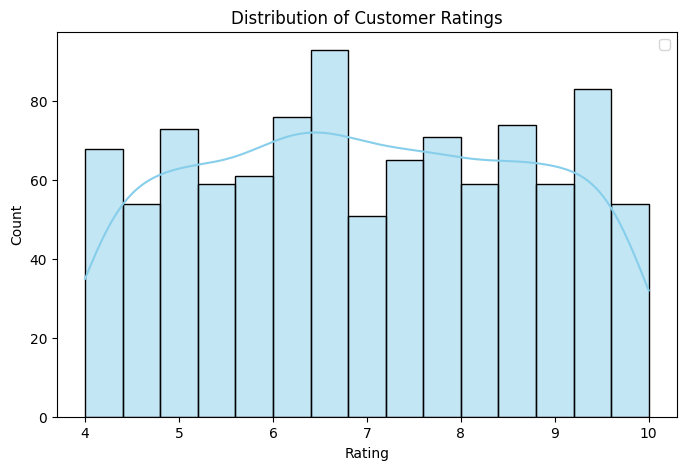

In [5]:
plt.figure(figsize=(8,5))

# Histogram with KDE
sns.histplot(
    data=df,
    x="Rating",
    bins=15,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

# Legend
plt.legend()

# Show plot
plt.show()

Insight: It looks like an uniform distribution. The ratings do not spike. There seems to be equal chance of customer rating 4 or 10.
         Hence the distribution of the rating seems to be uniform and not skewed.

Question 2: Do aggregate sales number differ in different branches?

In [ ]:
df["Branch"].value_counts()

A    340
B    332
C    328
Name: Branch, dtype: int64

<AxesSubplot:xlabel='Branch', ylabel='count'>

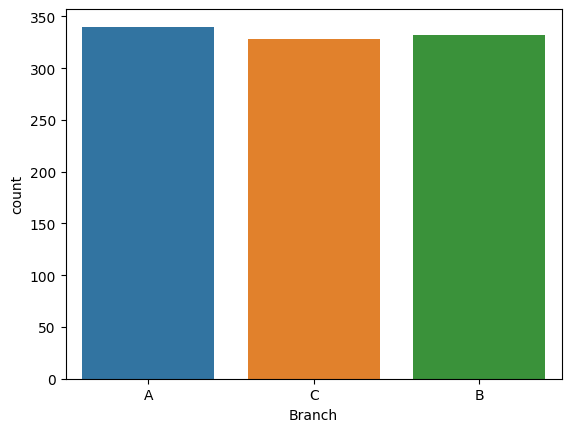

In [ ]:
sns.countplot(x = df["Branch"])

In [ ]:
df["Payment"].value_counts()

Ewallet        345
Cash           344
Credit card    311
Name: Payment, dtype: int64

<AxesSubplot:xlabel='Payment', ylabel='count'>

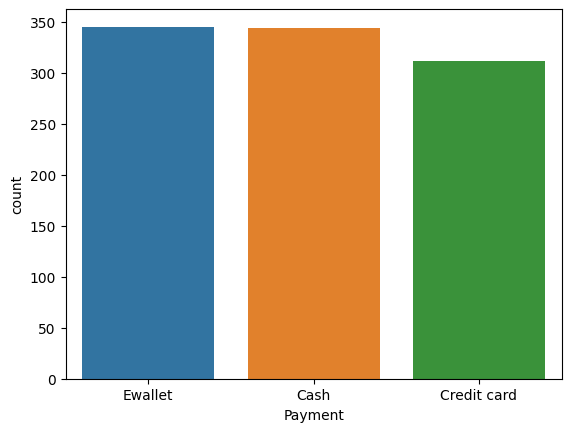

In [ ]:
sns.countplot(x = df["Payment"])

In [ ]:
df["Customer type"].value_counts()

Member    501
Normal    499
Name: Customer type, dtype: int64

<AxesSubplot:xlabel='Customer type', ylabel='count'>

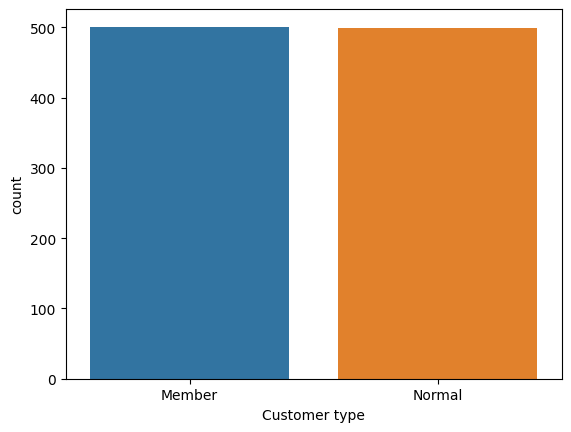

In [ ]:
sns.countplot(x = df["Customer type"])

# Bivariate Analysis

Is there a relationship between gross income and customer ratings?

<AxesSubplot:xlabel='Rating', ylabel='gross income'>

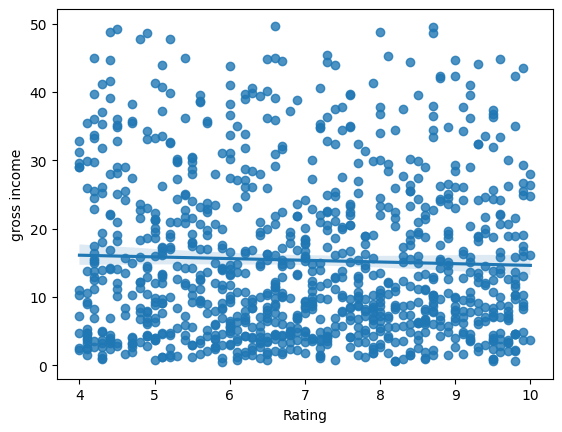

In [ ]:
sns.regplot(x = df["Rating"], y = df["gross income"])

Insight: It doesnt seem that rating and income has any variation.

<AxesSubplot:xlabel='Branch', ylabel='gross income'>

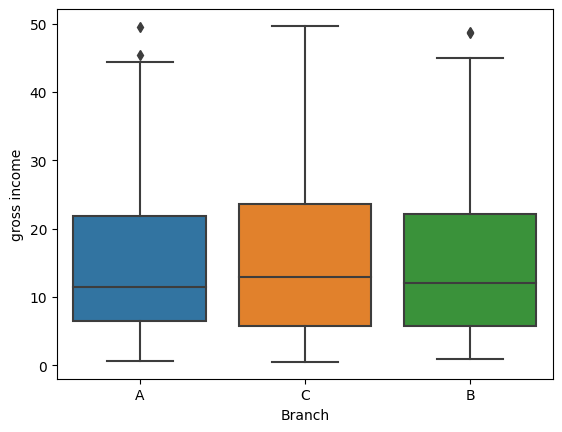

In [ ]:
sns.boxplot(x = df["Branch"], y = df["gross income"])

Insight: It doesnt seem that rating and income has any much variation.

<AxesSubplot:xlabel='Gender', ylabel='gross income'>

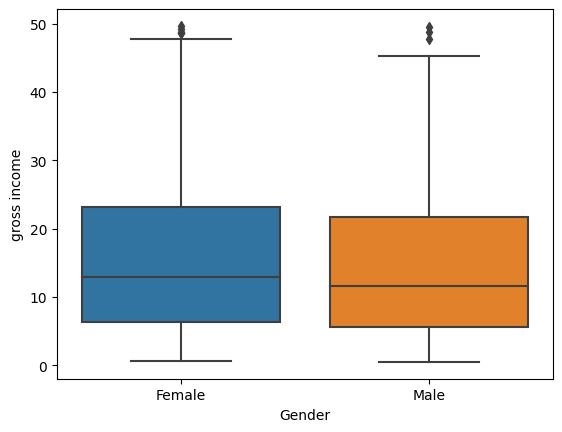

In [ ]:
sns.boxplot(x = df["Gender"], y = df["gross income"])

Insight: Both Men and Women have similar average gross income.

Question 4: Is there noticeable time trend in gross income?

Aggregating the dataframe based on the Rating

In [ ]:
df.groupby(df["Rating"]).mean()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income
Rating,,,,,,,
4.0,62.893636,5.000000,17.257636,362.410364,345.152727,4.761905,17.257636
4.1,47.598824,4.411765,10.053735,211.128441,201.074706,4.761905,10.053735
4.2,59.446818,6.818182,20.077727,421.632273,401.554545,4.761905,20.077727
4.3,47.851111,5.555556,15.762194,331.006083,315.243889,4.761905,15.762194
4.4,58.118235,5.705882,18.813912,395.092147,376.278235,4.761905,18.813912
...,...,...,...,...,...,...,...
9.6,56.368824,5.823529,15.664588,328.956353,313.291765,4.761905,15.664588
9.7,51.442143,4.642857,11.334679,238.028250,226.693571,4.761905,11.334679
9.8,58.212632,4.368421,12.473500,261.943500,249.470000,4.761905,12.473500


Aggregating the dataframe based on the index(Date)

In [ ]:
groupeddf = df.groupby(df.index).mean()
groupeddf

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
Date,,,,,,,,
2019-01-01,54.995833,6.750000,18.830083,395.431750,376.601667,4.761905,18.830083,6.583333
2019-01-02,44.635000,6.000000,11.580375,243.187875,231.607500,4.761905,11.580375,6.050000
2019-01-03,59.457500,4.625000,12.369813,259.766062,247.396250,4.761905,12.369813,8.112500
2019-01-04,51.743333,5.333333,12.886417,270.614750,257.728333,4.761905,12.886417,6.516667
2019-01-05,61.636667,4.583333,14.034458,294.723625,280.689167,4.761905,14.034458,7.433333
...,...,...,...,...,...,...,...,...
2019-03-26,42.972308,4.000000,7.188692,150.962538,143.773846,4.761905,7.188692,6.623077
2019-03-27,56.841000,4.500000,13.822950,290.281950,276.459000,4.761905,13.822950,6.760000
2019-03-28,45.525000,4.800000,10.616200,222.940200,212.324000,4.761905,10.616200,7.050000


<AxesSubplot:xlabel='Date', ylabel='gross income'>

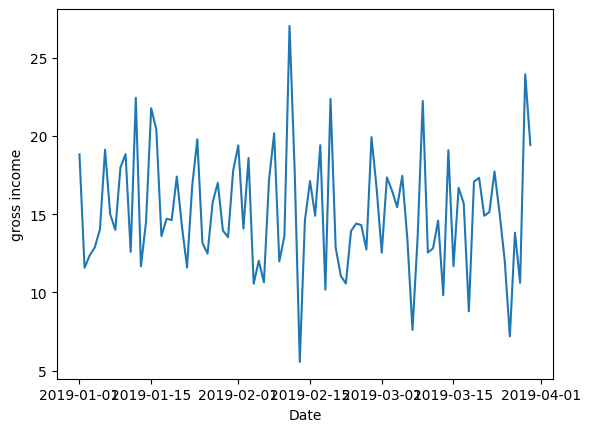

In [ ]:
sns.lineplot(x = groupeddf.index, y = groupeddf["gross income"])

# Removing duplicate indexes

In [ ]:
df.index.is_unique

False

In [ ]:
df.index.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True, False, False, False, False, False,  True,
       False, False,  True,  True, False,  True,  True,  True, False,
        True,  True, False,  True, False, False,  True, False, False,
        True, False,  True, False, False, False,  True,  True,  True,
       False, False, False,  True, False, False, False,  True,  True,
       False, False, False,  True,  True, False,  True, False, False,
        True,  True, False, False, False, False,  True,  True,  True,
       False, False, False,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True, False, False, False, False,  True,  True,  True,  True,
       False,  True, False,  True,  True, False,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,

In [ ]:
df.index.duplicated()
new_df = df.loc[~df.index.duplicated(), :]

In [ ]:
print("After removing duplicate indexes Rows: {}, Columns: {}".format(new_df.shape[0], new_df.shape[1]))

After removing duplicate indexes Rows: 89, Columns: 16


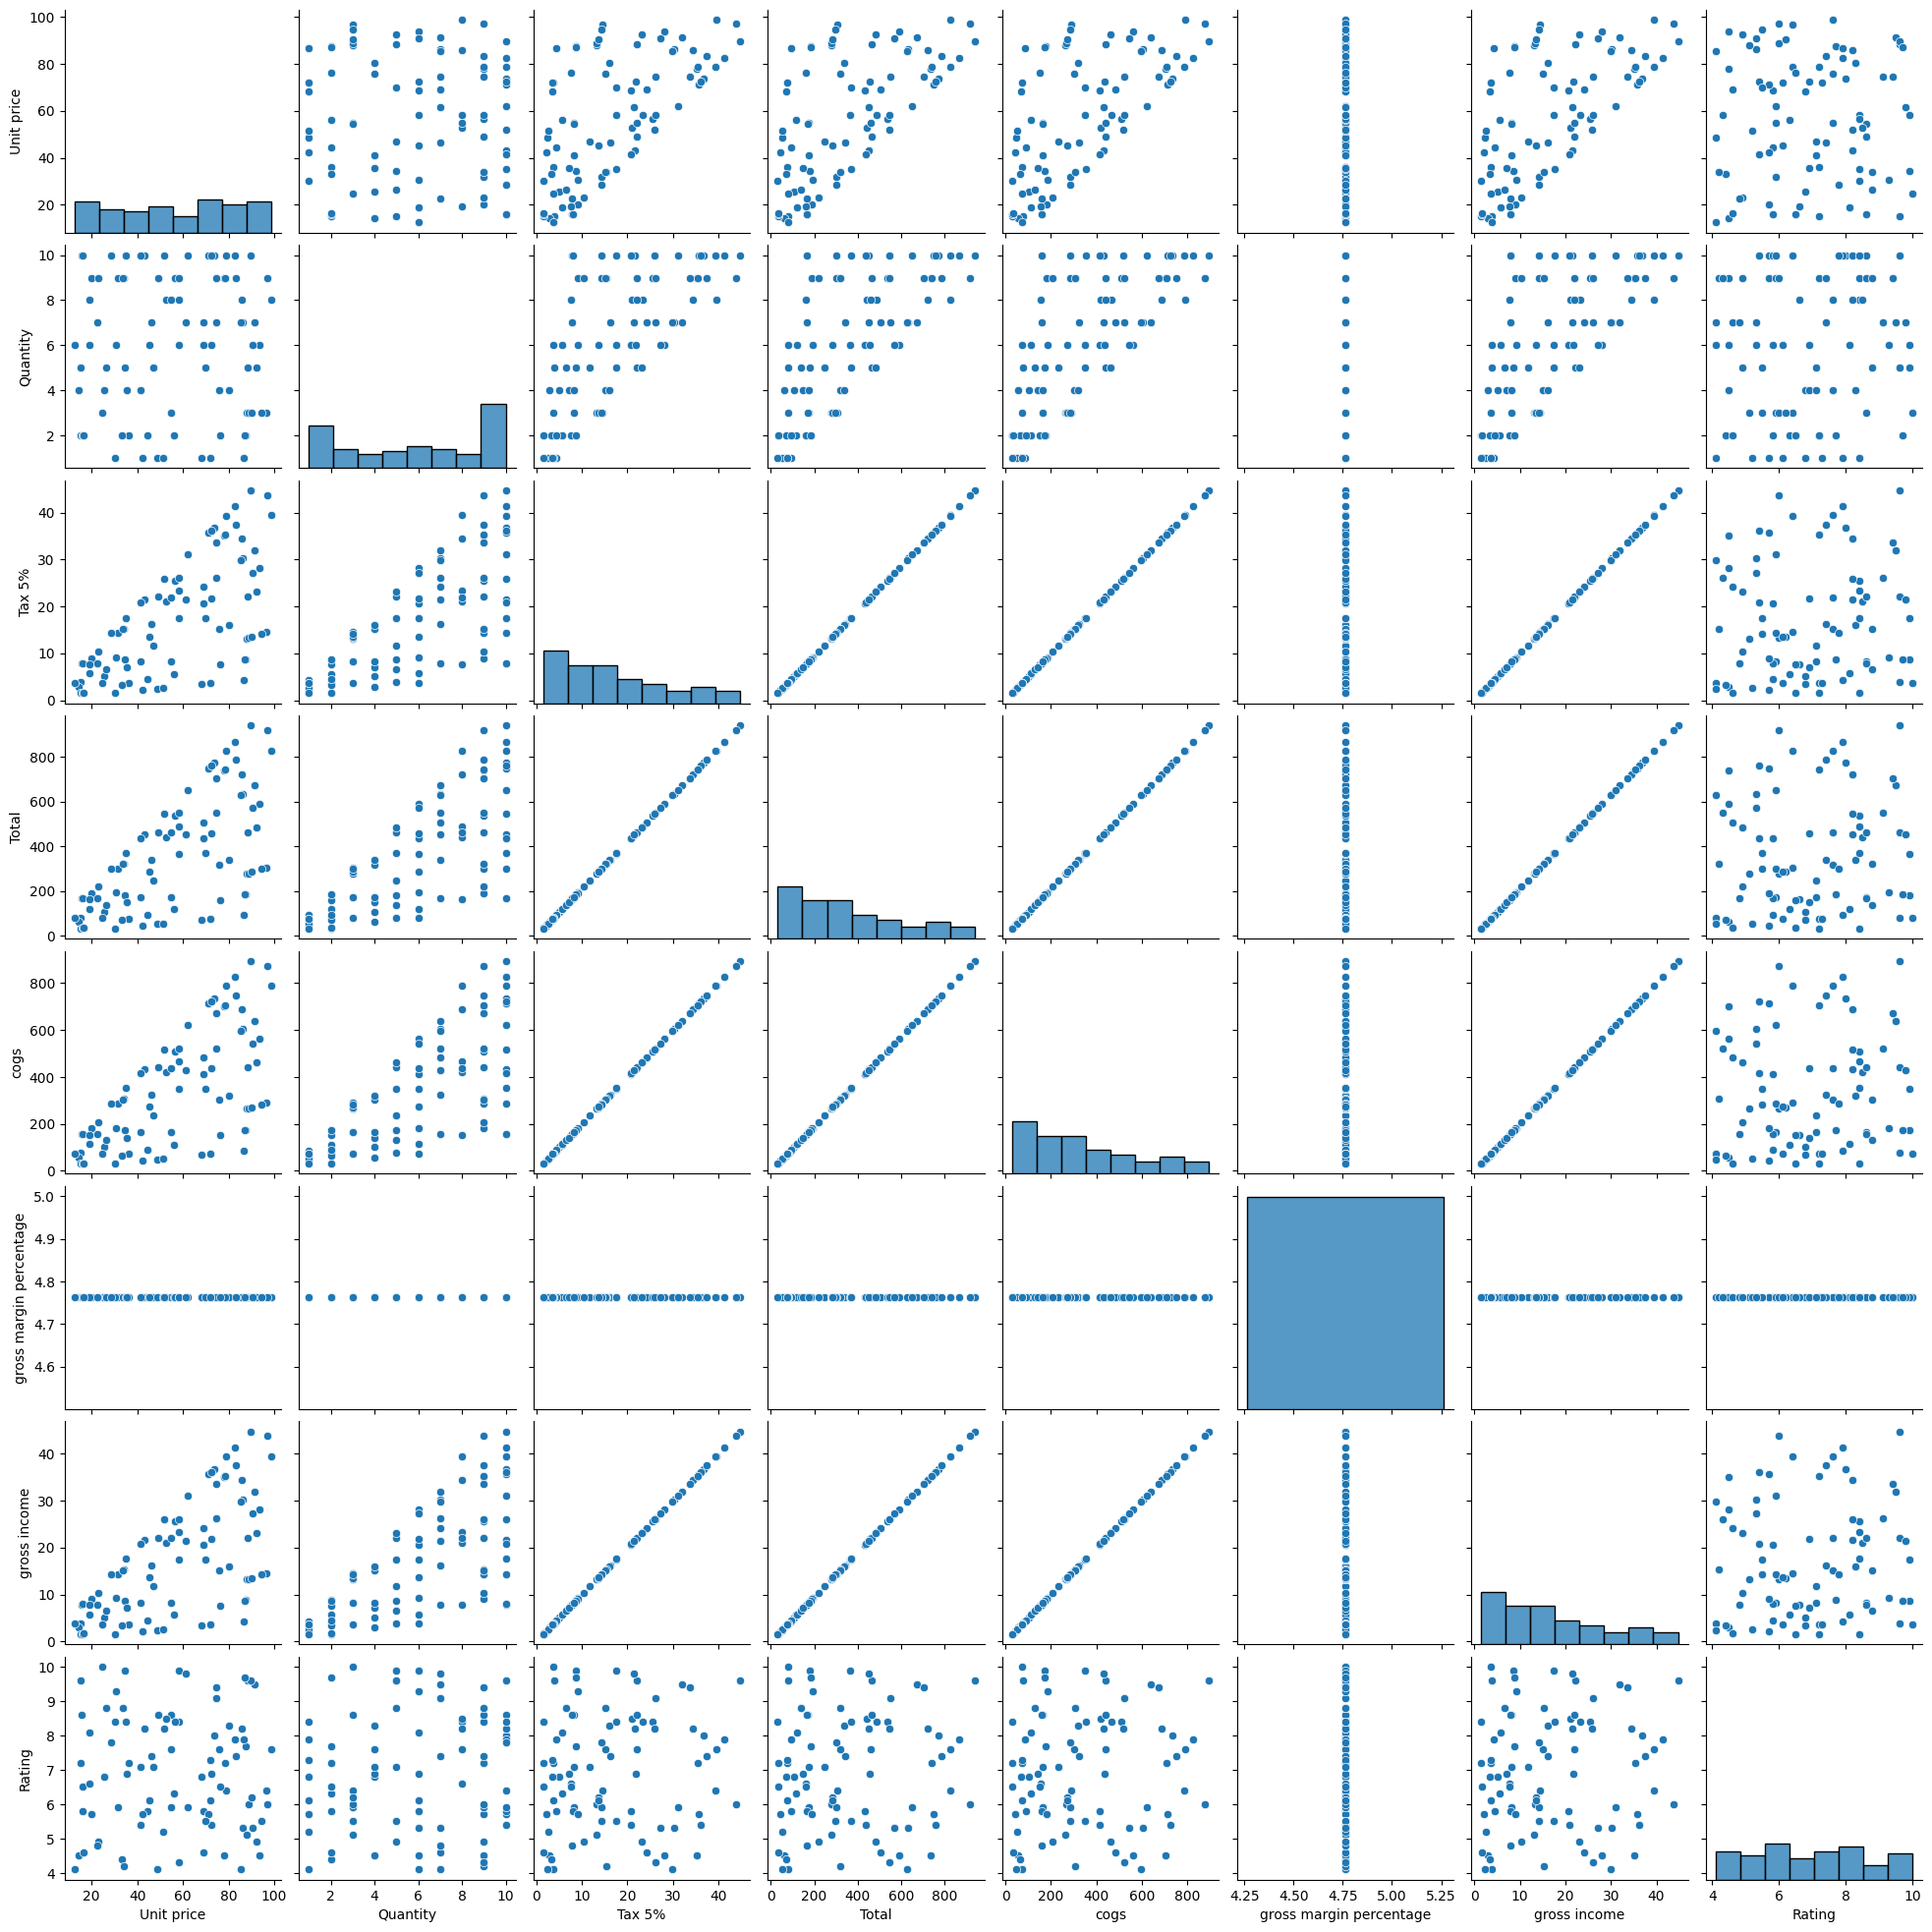

In [ ]:
sns.pairplot(new_df)

# Dealing with duplicate rows and missing values

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.isna().sum()
# df.isna().sum()/len(df) (Ratio of missing values)

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

<AxesSubplot:ylabel='Date'>

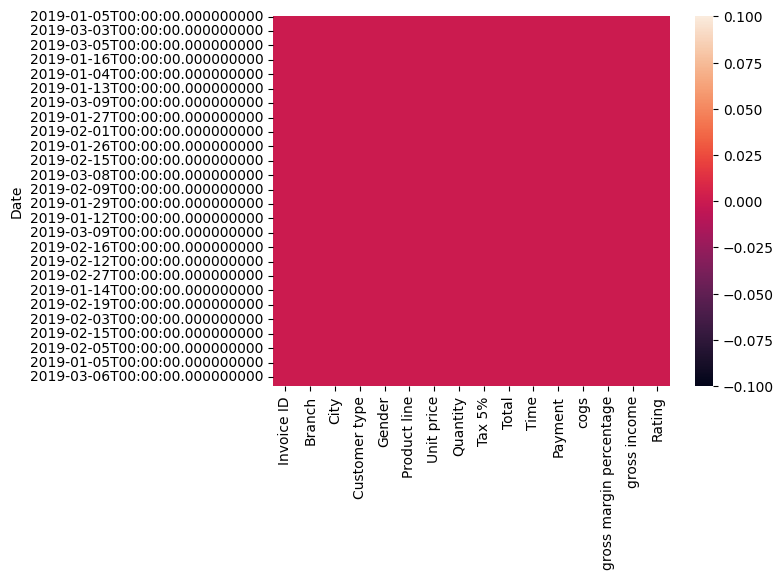

In [ ]:
sns.heatmap(df.isnull())

In [ ]:
# Dealing with null values.Commenting it since have no null values in dataframe.
#df.fillna(0, inplace = True)
#df.fillna(df.mean(), inplace = True)
#df.fillna(df.mode().iloc[0], inplace = True)

In [ ]:
df.fillna(df.mode().iloc[0], inplace = True)

# Correlation Analysis

In [ ]:
np.corrcoef(df["gross income"], df["Rating"])

array([[ 1.       , -0.0364417],
       [-0.0364417,  1.       ]])

In [ ]:
np.corrcoef(df["Unit price"], df["Quantity"])

array([[1.        , 0.01077756],
       [0.01077756, 1.        ]])

In [ ]:
round(df.corr(), 2)

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
Unit price,1.00,0.01,0.63,0.63,0.63,NaN,0.63,-0.01
Quantity,0.01,1.00,0.71,0.71,0.71,NaN,0.71,-0.02
Tax 5%,0.63,0.71,1.00,1.00,1.00,NaN,1.00,-0.04
Total,0.63,0.71,1.00,1.00,1.00,NaN,1.00,-0.04
cogs,0.63,0.71,1.00,1.00,1.00,NaN,1.00,-0.04
gross margin percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross income,0.63,0.71,1.00,1.00,1.00,NaN,1.00,-0.04
Rating,-0.01,-0.02,-0.04,-0.04,-0.04,NaN,-0.04,1.00


<AxesSubplot:>

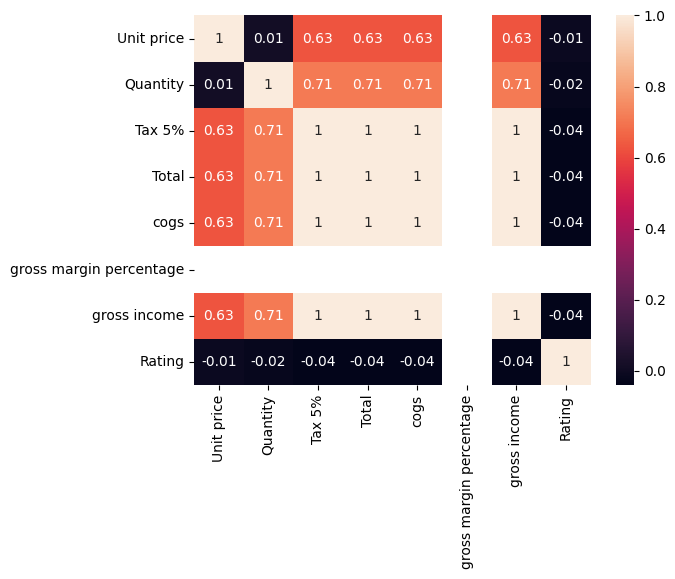

In [ ]:
sns.heatmap(round(df.corr(), 2), annot = True)